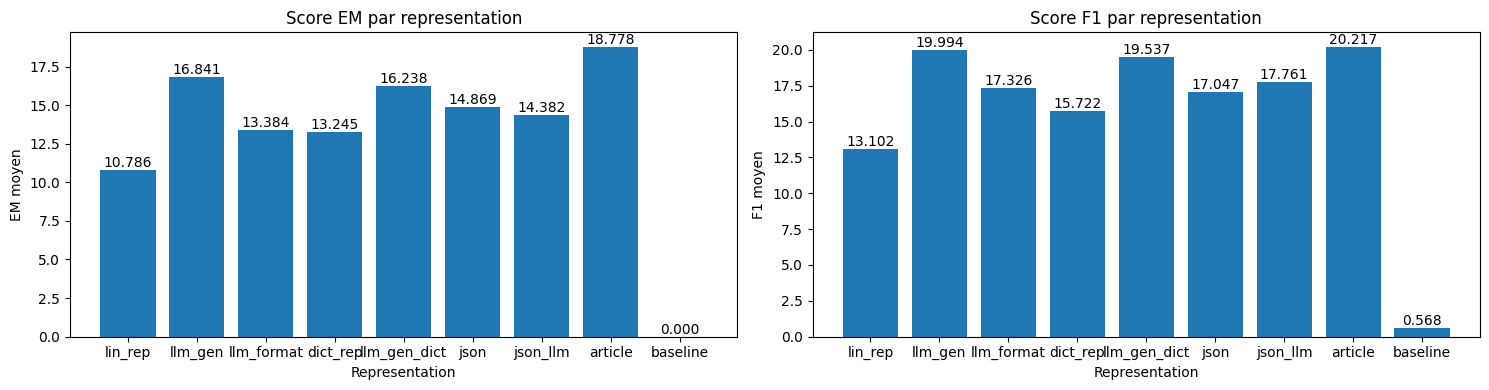

In [11]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
path = "WikiTableQuestions-1.0.2-compact/WikiTableQuestions/" 
map =map_rep={
    0: "lin_rep",
    1: "llm_gen",
    2: "llm_format",
    3: "dico",
    4:"article",
    5:"baseline"
}
map={
    0: "lin_rep",
    1: "llm_gen",
    2: "llm_format",
    3: "dict_rep",
    4:"llm_gen_dict",
    5: "json",
    6: "json_llm",
    7:"article",
    8: "baseline",
}

files = sorted(glob.glob(os.path.join(path, "qa_res_test_*.csv")))
results = {}
for file in files:
    method = os.path.splitext(os.path.basename(file))[0].split("_")[-1]
    df = pd.read_csv(file)

    em_cols = [c for c in df.columns if c.startswith("EM_stat_score")]
    f1_cols = [c for c in df.columns if c.startswith("F1_stat_score")]

    mean_em = df[em_cols].mean().mean()
    mean_f1 = df[f1_cols].mean().mean()

    results[method] = {"EM": mean_em, "F1": mean_f1}

res_df = pd.DataFrame.from_dict(results, orient='index')
res_df = res_df.sort_index()

fig, axis = plt.subplots(1,2,figsize= (15,4))
ax = axis[0]
bars =ax.bar(res_df.index, res_df["EM"])
ax.bar_label(bars, fmt='%.3f') 
ax.set_xticks([0,1,2,3,4,5,6,7,8])
ax.set_xticklabels(map.values())
ax.set_xlabel("Representation")
ax.set_ylabel("EM moyen")
ax.set_title("Score EM par representation")
ax = axis[1]
bars =ax.bar(res_df.index, res_df["F1"])
ax.bar_label(bars, fmt='%.3f') 
ax.set_xticks([0,1,2,3,4,5,6,7,8])
ax.set_xticklabels(map.values())
ax.set_xlabel("Representation")
ax.set_ylabel("F1 moyen")
ax.set_title("Score F1 par representation")
plt.tight_layout()
plt.show()


In [25]:
unseen_data = pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_pristine-unseen-tables_cleaned.tagged")
qa_files = files

def merge_all_predictions(qa_files, df_unseen):
    merged = {}
    for file in qa_files:
        df_pred = pd.read_csv(file)
        title = file.split(".csv")[0]
        #recup les colonnes EM et F1
        pred_col = [c for c in df_pred.columns if c.startswith("pred")][0]
        em_col = [c for c in df_pred.columns if c.startswith("EM_stat_score")][0]
        f1_col = [c for c in df_pred.columns if c.startswith("F1_stat_score")][0]
        df_temp = df_unseen.merge(df_pred[['id', pred_col, em_col, f1_col]], on='id')
        df_temp = df_temp.rename(columns={
            pred_col: 'pred',
            em_col: 'EM_score',
            f1_col: 'F1_score'
        })
        merged[title] = df_temp
    return merged

def plot_percentage_correct_all(merged_dict, group_col):
    #recup toutes les categories de reponses possibles
    categories = merged_dict[list(merged_dict.keys())[0]][group_col].unique()
    categories.sort()
    
    fig, ax = plt.subplots(figsize=(15,4))
    width = 0.8 / len(merged_dict)
    for i, (name, df) in enumerate(merged_dict.items()):
        x_positions = [x + i*width for x in range(len(categories))]
        counts = df.groupby(group_col)['EM_score'].mean()
        counts = counts.reindex(categories, fill_value=0)
        ax.bar([x + i*width for x in range(len(categories))], counts, width=width, label=map[i])
        for x, val in zip(x_positions, counts):
            ax.text(x, val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color='black')
    
    
    ax.set_title(f'Percentage of Correct Predictions by {group_col}')
    ax.set_xlabel(group_col)
    ax.set_ylabel('% Correct')
    ax.set_xticks([x + width*(len(merged_dict)/2-0.5) for x in range(len(categories))])
    ax.set_xticklabels(categories, rotation=45)
    ax.legend(loc='upper center')
    plt.tight_layout()
    plt.show()


def plot_correct_vs_incorrect_all(merged_dict, group_col,t_or_f = False):
    fig, axis = plt.subplots(1,2,figsize=(18,5))
    formatted = ' '.join(word.capitalize() for word in group_col.split('_'))
    n_datasets = len(merged_dict)
    width = .6
    print(range(len(merged_dict)))
    all_categories = merged_dict[list(merged_dict.keys())[0]][group_col].unique()
    all_categories.sort()
    colors = plt.cm.twilight(np.linspace(0, 1, len(all_categories)))
    colors = plt.colormaps['tab20c'](np.linspace(0,1, len(all_categories)))
    labels = []
    for i,(name,df) in enumerate(merged_dict.items()):
        labels.append(name[-1])
        df['correct'] = df['EM_score'].apply(lambda x: 1 if x==1 or x==100.0 else 0)
        counts_correct = df[df['correct']==1].groupby(group_col).size().reindex(all_categories, fill_value=0)
        counts_incorrect = df[df['correct']==0].groupby(group_col).size().reindex(all_categories, fill_value=0)
        bottom_correct = 0
        bottom_incorrect = 0
        for j, cat in enumerate(all_categories):
            val = (counts_correct[cat]/counts_correct.sum())*100
            ax = axis[0]
            #correcte
            if val > 0:
                ax.bar(i , val, width=width, bottom=bottom_correct, color=colors[j])
                ax.text(i , bottom_correct + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color='black')
            bottom_correct += val
            ax.set_xticks(range(len(merged_dict)))
            ax.set_xticklabels(map.values())
            if t_or_f:
                ax.set_ylabel(f'Quantity  in %')
            else:
                ax.set_ylabel(f'{formatted}  in %')
            ax.set_title(f'{formatted} Percentage in Correct Answers')
            ax.set_xlim(-1,9)
            ax = axis[1]
            # incorrect
            val = (counts_incorrect[cat]/counts_incorrect.sum())*100
            if val > 0:
                ax.bar(i , val, width=width, bottom=bottom_incorrect, color=colors[j])
                ax.text(i , bottom_incorrect + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color='black')
            bottom_incorrect += val
    
            ax.set_xticks([0,1,2,3,4,5,6,7,8])
            ax.set_xticklabels(map.values())
            ax.set_title(f'{formatted} Percentage in Incorrect Answers')
    
    handles = [plt.Rectangle((0,0),1,1, color=colors[j], edgecolor='k') for j in range(len(all_categories))]
    if t_or_f:
        ax.legend(handles, ["True","False"], bbox_to_anchor=(1.05, 1))
    else:
        ax.legend(handles, all_categories, title='Categories', bbox_to_anchor=(1.05, 1))

    plt.tight_layout()
    plt.show()
merged_dict = merge_all_predictions(qa_files, unseen_data)

range(0, 9)


/tmp/ipykernel_5169/1286912710.py:67: RuntimeWarning: invalid value encountered in scalar divide
  val = (counts_correct[cat]/counts_correct.sum())*100
/tmp/ipykernel_5169/1286912710.py:67: RuntimeWarning: invalid value encountered in scalar divide
  val = (counts_correct[cat]/counts_correct.sum())*100
/tmp/ipykernel_5169/1286912710.py:67: RuntimeWarning: invalid value encountered in scalar divide
  val = (counts_correct[cat]/counts_correct.sum())*100
/tmp/ipykernel_5169/1286912710.py:67: RuntimeWarning: invalid value encountered in scalar divide
  val = (counts_correct[cat]/counts_correct.sum())*100
/tmp/ipykernel_5169/1286912710.py:67: RuntimeWarning: invalid value encountered in scalar divide
  val = (counts_correct[cat]/counts_correct.sum())*100
/tmp/ipykernel_5169/1286912710.py:67: RuntimeWarning: invalid value encountered in scalar divide
  val = (counts_correct[cat]/counts_correct.sum())*100
/tmp/ipykernel_5169/1286912710.py:67: RuntimeWarning: invalid value encountered in scala

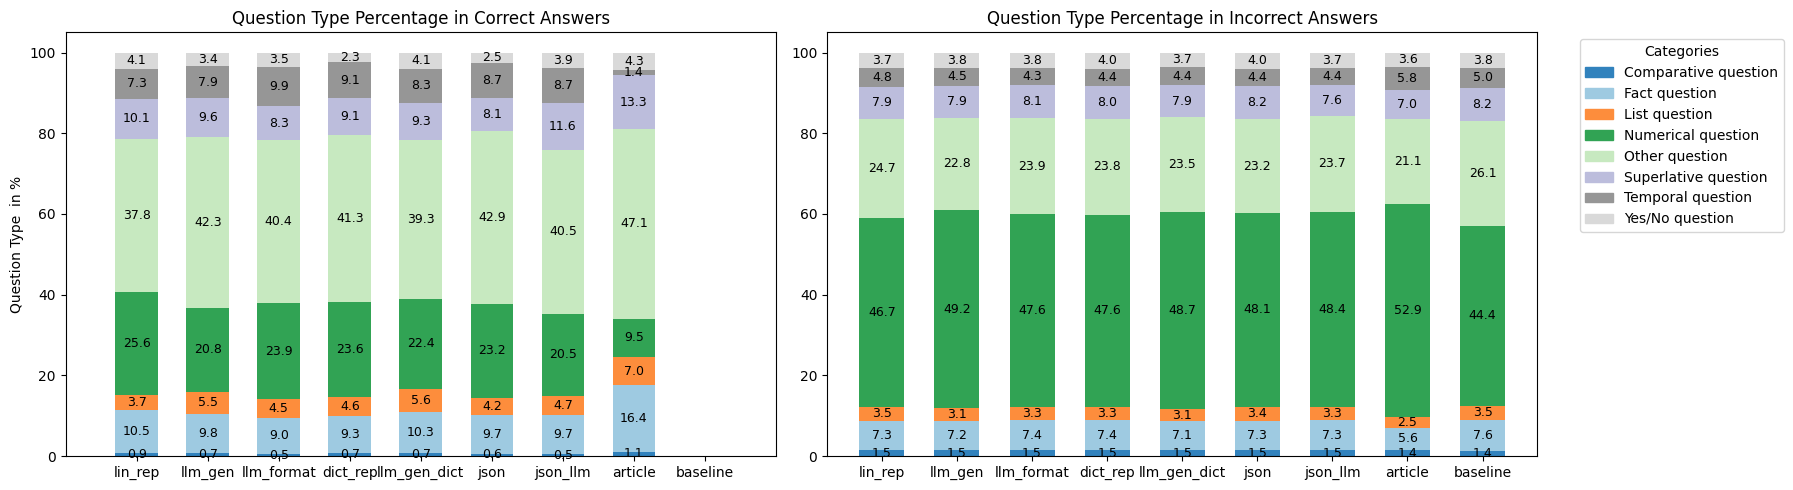

In [26]:
plot_correct_vs_incorrect_all(merged_dict, 'question_type')


les colonnes hachurées c'est les colonnes qui correspondent à une reponse incorrecte.
observations:\
-Predominances de reponses incorrectes\
-llm1 a le plus de reponses correctes toutes categories confondues\
-a ameliorer pour une meilleure lisibilité: normaliser les valeurs en fonction du nombre de questions par categorie

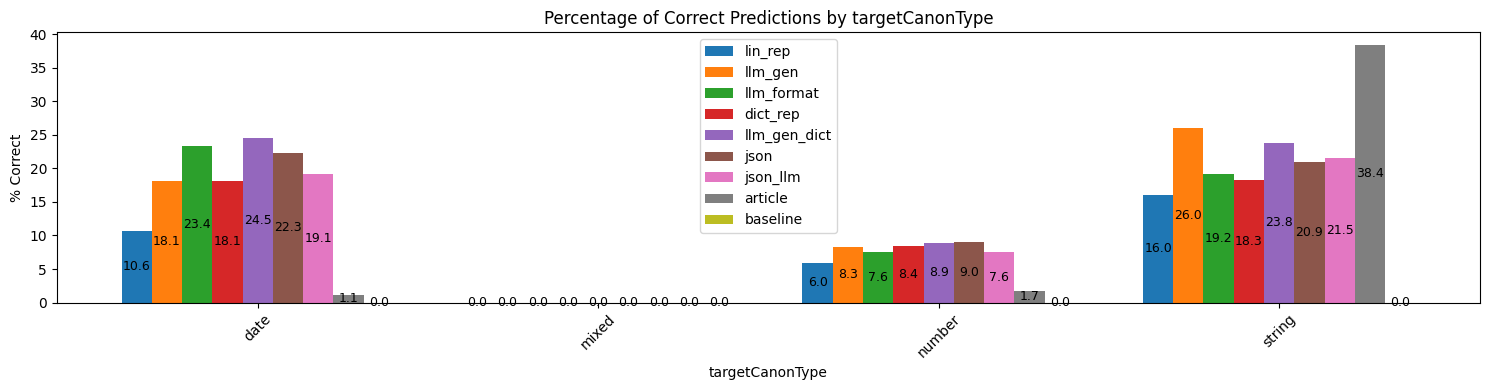

In [27]:
plot_percentage_correct_all(merged_dict, 'targetCanonType')


observations:\
-rpz dictionnaire pas de bonne reponse\
-plus de bonne reponses sur le types string\
-llm2 moins bon que rpz dictionnaire sauf pour les questions de type date\
-represenation dictionnaire est la plus performantes pour les reponses numeriques\

range(0, 9)


/tmp/ipykernel_5169/1286912710.py:67: RuntimeWarning: invalid value encountered in scalar divide
  val = (counts_correct[cat]/counts_correct.sum())*100
/tmp/ipykernel_5169/1286912710.py:67: RuntimeWarning: invalid value encountered in scalar divide
  val = (counts_correct[cat]/counts_correct.sum())*100
/tmp/ipykernel_5169/1286912710.py:94: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0,0),1,1, color=colors[j], edgecolor='k') for j in range(len(all_categories))]


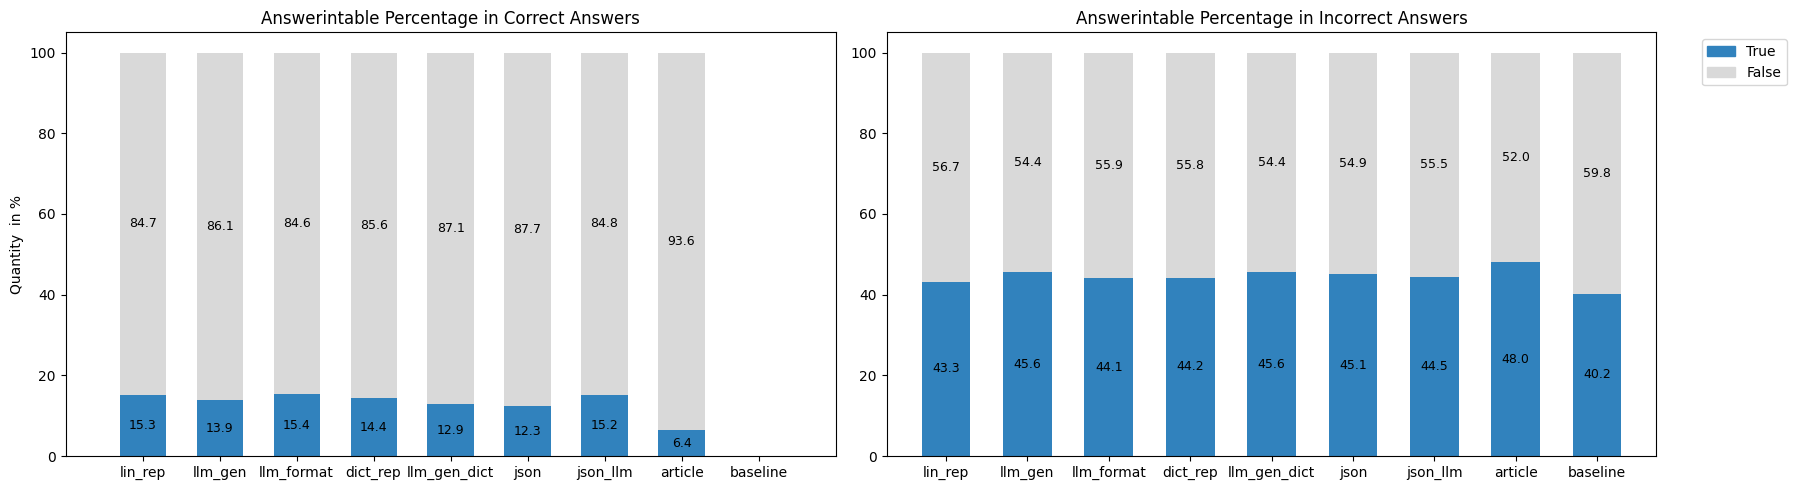

In [28]:
plot_correct_vs_incorrect_all(merged_dict, 'answerInTable',t_or_f=True)


observations:\
llm1 a le plus de bonne reponses\
a ameliorer normaliser en fonction par nombre de questions avec effectivement la reponse dans la table\
lorsque la reponses est incorrecte pas trop de difference si la reponses etait dans la table ou non par contre lorsque c'est la bonne reponse très souvent la reponse et dans la table (toutes rpz confondues)

range(0, 9)


/tmp/ipykernel_5169/1286912710.py:67: RuntimeWarning: invalid value encountered in scalar divide
  val = (counts_correct[cat]/counts_correct.sum())*100
/tmp/ipykernel_5169/1286912710.py:67: RuntimeWarning: invalid value encountered in scalar divide
  val = (counts_correct[cat]/counts_correct.sum())*100
/tmp/ipykernel_5169/1286912710.py:94: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0,0),1,1, color=colors[j], edgecolor='k') for j in range(len(all_categories))]


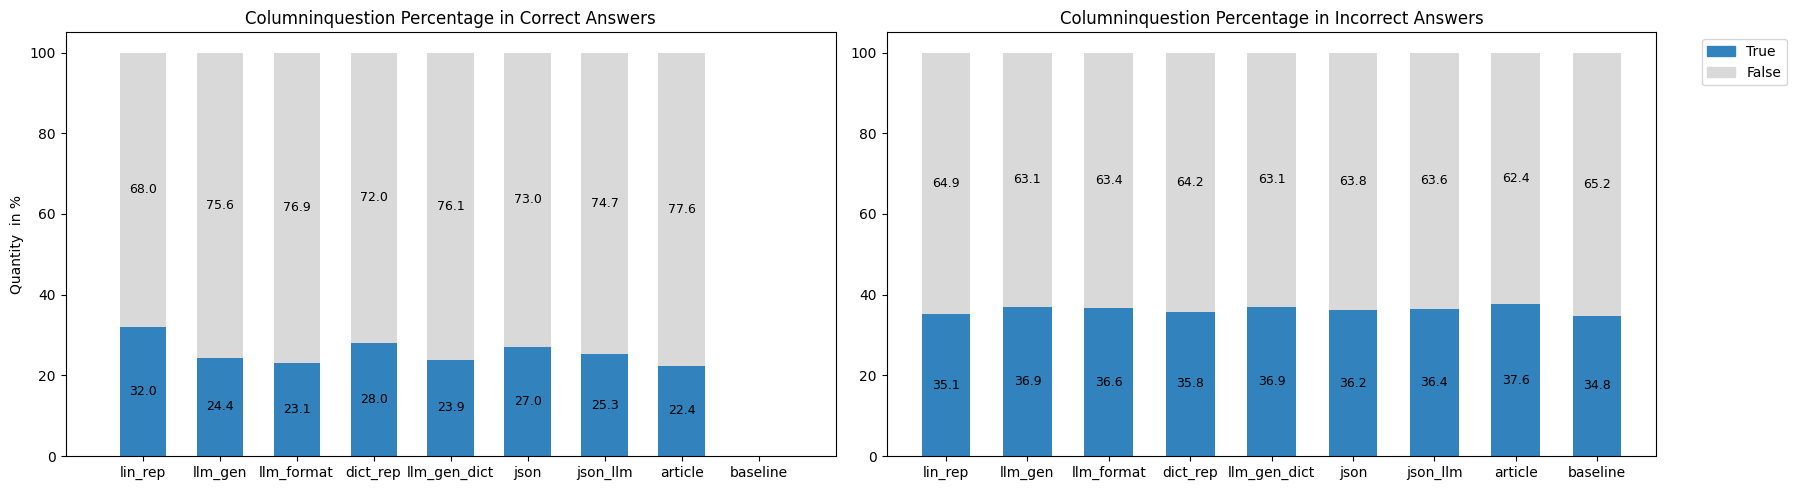

In [29]:
plot_correct_vs_incorrect_all(merged_dict, 'columnInQuestion',True)


observation similaire a la figure au dessus

PROBLEME DE VISUALISATION
faut modifier les fichiers csv car la colonne EM en fonction de la representation contient des 0 ou des 1 mais parfois elle contient des 0.0 et 100.0 donc peut poser pb dans les figures ci dessus normalement c'est gerer mais faudra penser a les modifier pour que ce soit bien partout les memes valeurs d'em score

In [30]:
article_test_res = pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/test-predictions.tsv", sep = "\t", on_bad_lines= "skip", header = None, names = ["id", "pred"])
data = pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_pristine-unseen-tables_cleaned.tagged")
target = data[["id",'targetValue']]
merged = article_test_res.merge(data[["id", "targetValue"]], on="id", how="left")
t0= merged_dict['WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_test_0']
merged = merged[merged["id"].isin(t0["id"])]


In [31]:
from evaluate import load
metric = load("squad")
pred_formatted = [{"id": str(i), "prediction_text": p} for i, p in enumerate(merged[f'pred'].tolist())]
target_formatted  = [{"id": str(i), "answers": {"text": [t], "answer_start": [0]}}  # answer_start ignored
         for i, t in enumerate(merged['targetValue'].tolist())]

i=0
scores=[]
for pred, ref in zip(pred_formatted, target_formatted):
    if i%100==0: print(i)
    try:
        s = metric.compute(predictions=[pred], references=[ref])
    except Exception as e:
        print(f"Erreur index {i}: {e}")
        s = {"f1": 0.0, "exact_match": 0.0}
    scores.append(s)
    i+=1

merged["F1_stat_score_pred"] = [s["f1"] for s in scores]
merged["EM_stat_score_pred"] = [s["exact_match"] for s in scores]
merged.to_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_train_4.csv")

KeyboardInterrupt: 

In [14]:
merged.to_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_train_4.csv")